In [31]:
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import librosa
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
import numpy as np
import os
from scipy.signal import butter, filtfilt


LOWCUT, HIGHCUT = 20, 500   
SEGMENT_EXTENSION_MS = 7   
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low, high = lowcut / nyq, highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(signal_uV, fs):
    b, a = butter_bandpass(20, 500, fs, order=4)
    return filtfilt(b, a, signal_uV)


data = "./absolute-features/features.csv"

df = pd.read_csv(data)

print("Loading and filtering all unique audio files...")
filtered_signals = {} 

for file_path in df["file"].unique():
    print(f"Filtering: {file_path}")
    signal, fs = librosa.load(file_path)
    
    signal_filtered = apply_bandpass_filter(signal, fs)
    filtered_signals[file_path] = (signal_filtered, fs)

print(f"Filtered {len(filtered_signals)} unique audio files\n")

Loading and filtering all unique audio files...
Filtering: .\Spontanaktivität\filtered_BA0803901_segment_1.wav
Filtering: .\Spontanaktivität\filtered_BA0803901_segment_2.wav
Filtering: .\Spontanaktivität\filtered_BA0803901_segment_3.wav
Filtering: .\Spontanaktivität\filtered_BP0803902_segment_1.wav
Filtering: .\Spontanaktivität\filtered_HC280963_segment_1.wav
Filtering: .\Spontanaktivität\filtered_HC280963_segment_2.wav
Filtering: .\Spontanaktivität\filtered_LI06056410_segment_1.wav
Filtering: .\Spontanaktivität\filtered_LI0605644_segment_1.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_1.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_2.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_3.wav
Filtering: .\Spontanaktivität\filtered_LI0605645_segment_4.wav
Filtering: .\Spontanaktivität\filtered_LI0605648_segment_2.wav
Filtering: .\Spontanaktivität\filtered_QD161095_segment_5.wav
Filtering: .\Spontanaktivität\filtered_RN181281_segment_1.wav
Filtering:

In [32]:

df["segment"] = None

for index, row in df.iterrows():
    file_path = row["file"]
    signal_filtered, fs = filtered_signals[file_path]
    
    start_sample = row["Start"]
    end_sample = row["End"]
    
    start_sample = int(start_sample * fs)
    end_sample = int(end_sample * fs)
    extension_samples = int((SEGMENT_EXTENSION_MS / 1000) * fs)
    
    extended_start = max(0, start_sample - extension_samples)
    extended_end = min(len(signal_filtered), end_sample + extension_samples)
    
    segment = signal_filtered[extended_start:extended_end]
    df.at[index, "segment"] = segment

    if (index + 1) % 10 == 0:
        print(f"Processed {index + 1}/{len(df)} segments")

max_len = max(len(segment) for segment in df["segment"]) 

def pad_segment(segment, max_len):
    if len(segment) > max_len:
        return segment[:max_len]           
    else:
        return np.pad(segment, (0, max_len - len(segment)))  

features = []

segments = np.array([pad_segment(seg, max_len) for seg in df["segment"]])
features.append(segments)

X = np.stack(features, axis=-1)
print("X shape:", X.shape)  
print("Feature channels:", len(features))

def remap_label(label):
    label_lower = str(label).strip().lower()
    if label_lower in ['psw', 'fibrillation']:
        return 'positive'
    elif label_lower == 'none':
        return 'none'
    else:
        return label  

df['Label_Remapped'] = df['Label'].apply(remap_label)
y = df['Label_Remapped']

print("\nLabel distribution:")
print(y.value_counts())

le = LabelEncoder()
y = le.fit_transform(y)

print("\nEncoded labels:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Segments extended by ±{SEGMENT_EXTENSION_MS}ms and filtered globally (20-500 Hz)!")

Processed 10/3509 segments
Processed 20/3509 segments
Processed 30/3509 segments
Processed 40/3509 segments
Processed 50/3509 segments
Processed 60/3509 segments
Processed 70/3509 segments
Processed 80/3509 segments
Processed 90/3509 segments
Processed 100/3509 segments
Processed 110/3509 segments
Processed 120/3509 segments
Processed 130/3509 segments
Processed 140/3509 segments
Processed 150/3509 segments
Processed 160/3509 segments
Processed 170/3509 segments
Processed 180/3509 segments
Processed 190/3509 segments
Processed 200/3509 segments
Processed 210/3509 segments
Processed 220/3509 segments
Processed 230/3509 segments
Processed 240/3509 segments
Processed 250/3509 segments
Processed 260/3509 segments
Processed 270/3509 segments
Processed 280/3509 segments
Processed 290/3509 segments
Processed 300/3509 segments
Processed 310/3509 segments
Processed 320/3509 segments
Processed 330/3509 segments
Processed 340/3509 segments
Processed 350/3509 segments
Processed 360/3509 segments
P

In [33]:
# Print available columns
print("Available columns:", df.columns.tolist())

Available columns: ['Start', 'End', 'Label', 'Start Sample', 'End Sample', 'len', 'mean', 'std', 'rms', 'mav', 'iEMG', 'wl', 'zcr', 'spec_entropy', 'median_freq', 'skew', 'kurtosis', 'file', 'segment', 'Label_Remapped']
 ['Start', 'End', 'Label', 'Start Sample', 'End Sample', 'len', 'mean', 'std', 'rms', 'mav', 'iEMG', 'wl', 'zcr', 'spec_entropy', 'median_freq', 'skew', 'kurtosis', 'file', 'segment', 'Label_Remapped']


In [ ]:


from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

n_channels = X.shape[-1]
print(f"Number of input channels: {n_channels}")

model = Sequential([
    Conv1D(64, 7, activation='relu', padding='same', input_shape=(max_len, n_channels)),  # Updated input shape
    MaxPooling1D(2),
    Conv1D(128, 5, activation='relu', padding='same'),
    MaxPooling1D(2),
    Conv1D(256, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')
])

# f1 macro berechnen, precision und recall
# zuerst spontanaktivität und normal
# matrix
# schauen dass ich nicht enzeln normalisiere
# global normalisieren statt relativ
# ohne dropout versuchen
# it could help to have a look at it from a mathematical perspective
# check out moritzs paper to see a reference
# Max pooling reduzieren und batch normalisierung vor dem pooling
# Entweder
# activation nur im Dense Schicht
# activation nach dem batch normalization
# Check the features what they mean, from random forest and see why they are so helpful for the model

Number of input channels: 1



c:\Users\joaqu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:

y_train.shape

(2807,)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

monitor = EarlyStopping(monitor='val_loss',
                        mode='min', 
                        restore_best_weights=True,
                        patience=5)

In [37]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_split=0.1,
                    callbacks=[monitor],
                    class_weight=class_weights)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - acc: 0.6865 - loss: 0.6644 - val_acc: 0.8078 - val_loss: 0.4544
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - acc: 0.6865 - loss: 0.6644 - val_acc: 0.8078 - val_loss: 0.4544
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - acc: 0.7770 - loss: 0.4331 - val_acc: 0.7972 - val_loss: 0.4308
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - acc: 0.7770 - loss: 0.4331 - val_acc: 0.7972 - val_loss: 0.4308
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - acc: 0.8007 - loss: 0.4062 - val_acc: 0.8648 - val_loss: 0.3500
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - acc: 0.8007 - loss: 0.4062 - val_acc: 0.8648 - val_loss: 0.3500
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - acc: 0.8120 - loss: 0.4162 - val_acc: 0.8790 - val_loss: 0.3454
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - acc: 0.8120 - loss: 0.4162 - val_acc: 0.8790 - val_loss: 0.3454
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - ac

In [38]:
# Check shapes and data types
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)
print("Number of unique classes in y_train:", len(np.unique(y_train)))
print("\nModel input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

X_train shape: (2807, 1155, 1)
y_train shape: (2807,)
X_train dtype: float64
y_train dtype: int32
Number of unique classes in y_train: 2

Model input shape: (None, 1155, 1)
Model output shape: (None, 2)



++++++++++++ Test data ++++++++++++
loss=0.2697 acc=0.8746


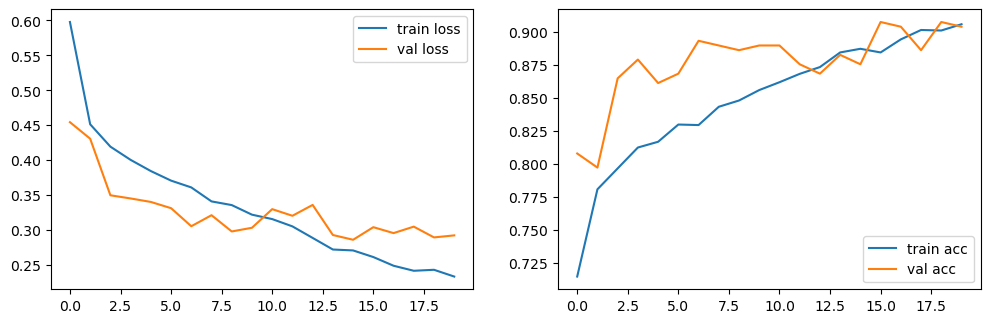

In [39]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['acc'], label='train acc')
plt.plot(history.history['val_acc'], label='val acc')
plt.legend()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n++++++++++++ Test data ++++++++++++\nloss={loss:.4f} acc={acc:.4f}")

# with badnpass, 7 90 accuracy

In [40]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 1155, 64)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 577, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 577, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 288, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 288, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 144, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,601,800 (55.70 MB)

 Trainable params: 4,867,266 (18.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,734,534 (37.13 MB)